# Body Composition Analysis
This notebook analyzes body composition changes based on fitness and lifestyle factors, predicting muscle definition and body fat changes.

In [1]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import seaborn as sns
from typing import List, Dict

# Load the data
try:
    df = pd.read_csv('fatLoss.csv')
    print('Dataset loaded successfully!')
except:
    print('Error loading dataset')
    exit()

print('Dataset Overview:')
print(df.head())
print('\nDataset Info:')
print(df.info())

Dataset loaded successfully!
Dataset Overview:
         exercise_name target_muscle_group      type  age gender  sets  reps  \
0  Barbell Bench Press               Chest  Compound   32      M     4    10   
1  Barbell Bench Press               Chest  Compound   28      F     3    12   
2  Barbell Bench Press               Chest  Compound   39      M     5     8   
3  Barbell Bench Press               Chest  Compound   35      F     4    10   
4  Barbell Bench Press               Chest  Compound   26      M     3    12   

   weight  frequency  protein  calories  sleep    experience  \
0      80          3      150      2800    7.5  Intermediate   
1      45          2      130      2600    7.2      Beginner   
2      90          4      170      3100    8.0      Advanced   
3      50          3      135      2700    7.4  Intermediate   
4      85          2      145      2750    7.6  Intermediate   

   genetic_advantage  actual_fat_loss  daily_deficit  current_weight  height  
0       

## Calculate Basal Metabolic Rate (BMR)
Using the Mifflin-St Jeor Equation to calculate BMR based on gender, weight, height, and age.

In [2]:
# Calculate BMR (Basal Metabolic Rate) using Mifflin-St Jeor Equation
df.loc[df['gender'] == 'M', 'BMR'] = (
    88.362
    + (13.397 * df.loc[df['gender'] == 'M', 'current_weight'])
    + (4.799 * df.loc[df['gender'] == 'M', 'height'])
    - (5.677 * df.loc[df['gender'] == 'M', 'age'])
)

df.loc[df['gender'] == 'F', 'BMR'] = (
    447.593
    + (9.247 * df.loc[df['gender'] == 'F', 'current_weight'])
    + (3.098 * df.loc[df['gender'] == 'F', 'height'])
    - (4.330 * df.loc[df['gender'] == 'F', 'age'])
)

## Feature Engineering
Calculate additional body composition metrics such as BMI, muscle mass index, and training intensity.

In [3]:
def calculate_body_composition_features(df):
    """Calculate additional features for body composition prediction"""
    
    # BMI (Body Mass Index)
    df['BMI'] = df['current_weight'] / ((df['height'] / 100) ** 2)
    
    # Estimate muscle mass based on training variables
    df['muscle_mass_index'] = (
        (df['weight'] * df['sets'] * df['reps'] * df['frequency']) / 1000 +
        (df['protein'] / 100) +
        df['genetic_advantage'] +
        (df['experience'].map({'Beginner': 1, 'Intermediate': 2, 'Advanced': 3}) * 0.5)
    )
    
    # Training intensity score
    df['training_intensity'] = (df['weight'] * df['sets'] * df['reps']) / df['current_weight']
    
    # Caloric efficiency
    df['caloric_efficiency'] = df['actual_fat_loss'] / (df['daily_deficit'] / 100)
    
    # Sleep quality factor
    df['sleep_quality'] = np.where(df['sleep'] >= 7.5, 1, df['sleep'] / 7.5)
    
    # Body size indicator
    df['body_size_index'] = (df['current_weight'] * df['height']) / 10000
    
    return df

# Apply body composition calculations
df = calculate_body_composition_features(df)

## Body Composition Prediction
Predict muscle definition and body fat percentage changes based on calculated features.

In [4]:
def predict_body_composition_changes(df):
    """Predict definition and body fat percentage changes"""
    
    df['predicted_definition'] = 0.0
    df['predicted_body_fat_change'] = 0.0
    df['estimated_current_bf'] = 0.0
    
    df['estimated_current_bf'] = np.where(
        df['gender'] == 'M',
        np.clip(1.20 * df['BMI'] - 23.13 * (df['muscle_mass_index'] / 10) + 
                16.2 - (df['genetic_advantage'] * 2), 8, 35),
        np.clip(1.48 * df['BMI'] - 18.58 * (df['muscle_mass_index'] / 10) + 
                21.3 - (df['genetic_advantage'] * 2), 12, 40)
    )
    
    muscle_threshold = df['muscle_mass_index'].quantile(0.7)
    size_threshold = df['body_size_index'].quantile(0.6)
    
    high_muscle_condition = (
        (df['muscle_mass_index'] >= muscle_threshold) & 
        (df['body_size_index'] >= size_threshold) & 
        (df['daily_deficit'] > 200)
    )
    
    df.loc[high_muscle_condition, 'predicted_definition'] = np.clip(
        (df.loc[high_muscle_condition, 'actual_fat_loss'] * 0.8) +
        (df.loc[high_muscle_condition, 'training_intensity'] / 10) +
        (df.loc[high_muscle_condition, 'genetic_advantage'] * 0.5) +
        np.random.normal(0, 0.5, sum(high_muscle_condition)),
        0, 10
    )
    
    df.loc[high_muscle_condition, 'predicted_body_fat_change'] = -np.clip(
        (df.loc[high_muscle_condition, 'daily_deficit'] / 100) *
        (df.loc[high_muscle_condition, 'caloric_efficiency']) *
        (1 + df.loc[high_muscle_condition, 'muscle_mass_index'] / 20),
        0.5, 6
    )
    
    low_muscle_condition = ~high_muscle_condition & (df['daily_deficit'] > 0)
    
    df.loc[low_muscle_condition, 'predicted_definition'] = 0
    
    df.loc[low_muscle_condition, 'predicted_body_fat_change'] = -np.clip(
        (df.loc[low_muscle_condition, 'daily_deficit'] / 150) *
        (df.loc[low_muscle_condition, 'caloric_efficiency'] * 0.8) *
        (0.5 + df.loc[low_muscle_condition, 'genetic_advantage'] / 10),
        0.2, 4
    )
    
    df['predicted_final_bf'] = df['estimated_current_bf'] + df['predicted_body_fat_change']
    df['predicted_final_bf'] = np.clip(df['predicted_final_bf'], 5, 45)
    
    return df

# Apply body composition predictions
df = predict_body_composition_changes(df)

## Prediction Function
Create a function to make predictions for new individuals based on input parameters.

In [5]:
def make_body_composition_prediction(
    age, gender, current_weight, height, 
    exercise_name, sets, reps, weight, frequency,
    protein, calories, sleep, experience, genetic_advantage, daily_deficit
):
    """Make a prediction for a new individual"""
    
    input_data = pd.DataFrame({
        'age': [age],
        'gender': [gender],
        'current_weight': [current_weight],
        'height': [height],
        'exercise_name': [exercise_name],
        'sets': [sets],
        'reps': [reps],
        'weight': [weight],
        'frequency': [frequency],
        'protein': [protein],
        'calories': [calories],
        'sleep': [sleep],
        'experience': [experience],
        'genetic_advantage': [genetic_advantage],
        'daily_deficit': [daily_deficit],
        'actual_fat_loss': [0]
    })
    
    input_data = calculate_body_composition_features(input_data)
    input_data = predict_body_composition_changes(input_data)
    
    return {
        'estimated_current_bf': round(input_data['estimated_current_bf'].iloc[0], 1),
        'predicted_definition': round(input_data['predicted_definition'].iloc[0], 1),
        'predicted_body_fat_change': round(input_data['predicted_body_fat_change'].iloc[0], 1),
        'predicted_final_bf': round(input_data['predicted_final_bf'].iloc[0], 1),
        'muscle_mass_index': round(input_data['muscle_mass_index'].iloc[0], 2),
        'high_muscle_potential': input_data['muscle_mass_index'].iloc[0] >= df['muscle_mass_index'].quantile(0.7)
    }

## Results and Analysis
Display summary statistics and example predictions for high and low muscle mass individuals.

In [6]:
print('\n' + '='*50)
print('BODY COMPOSITION ANALYSIS RESULTS')
print('='*50)

# Summary statistics
print(f'\nDataset size: {len(df)} individuals')
print(f"\nBody Composition Metrics:")
print(f"Average muscle mass index: {df['muscle_mass_index'].mean():.2f}")
print(f"High muscle mass threshold: {df['muscle_mass_index'].quantile(0.7):.2f}")

print(f"\nDefinition Predictions:")
high_def = df[df['predicted_definition'] > 0]
print(f"Individuals with predicted definition: {len(high_def)} ({len(high_def)/len(df)*100:.1f}%)")
print(f"Average definition score: {high_def['predicted_definition'].mean():.2f}")

print(f"\nBody Fat Changes:")
print(f"Average predicted body fat change: {df['predicted_body_fat_change'].mean():.2f}%")
print(f"Average estimated current body fat: {df['estimated_current_bf'].mean():.1f}%")
print(f"Average predicted final body fat: {df['predicted_final_bf'].mean():.1f}%")

# Example predictions
print('\n' + '='*50)
print('EXAMPLE PREDICTIONS')
print('='*50)

# Example 1: High muscle mass individual
example1 = make_body_composition_prediction(
    age=28, gender='M', current_weight=85, height=180,
    exercise_name='Barbell Bench Press', sets=4, reps=8, weight=100, frequency=4,
    protein=160, calories=2800, sleep=8.0, experience='Advanced', 
    genetic_advantage=4, daily_deficit=400
)

print('\nExample 1 - High Muscle Mass Individual:')
print(f"Estimated current body fat: {example1['estimated_current_bf']}%")
print(f"Predicted definition score: {example1['predicted_definition']}/10")
print(f"Predicted body fat change: {example1['predicted_body_fat_change']}%")
print(f"Predicted final body fat: {example1['predicted_final_bf']}%")
print(f"High muscle potential: {example1['high_muscle_potential']}")

# Example 2: Lower muscle mass individual
example2 = make_body_composition_prediction(
    age=35, gender='F', current_weight=65, height=165,
    exercise_name='Treadmill', sets=1, reps=1, weight=0, frequency=3,
    protein=100, calories=1800, sleep=7.0, experience='Beginner', 
    genetic_advantage=2, daily_deficit=300
)

print('\nExample 2 - Lower Muscle Mass Individual:')
print(f"Estimated current body fat: {example2['estimated_current_bf']}%")
print(f"Predicted definition score: {example2['predicted_definition']}/10")
print(f"Predicted body fat change: {example2['predicted_body_fat_change']}%")
print(f"Predicted final body fat: {example2['predicted_final_bf']}%")
print(f"High muscle potential: {example2['high_muscle_potential']}")


BODY COMPOSITION ANALYSIS RESULTS

Dataset size: 390 individuals

Body Composition Metrics:
Average muscle mass index: 10.25
High muscle mass threshold: 11.56

Definition Predictions:
Individuals with predicted definition: 95 (24.4%)
Average definition score: 10.00

Body Fat Changes:
Average predicted body fat change: -3.78%
Average estimated current body fat: 25.7%
Average predicted final body fat: 22.4%

EXAMPLE PREDICTIONS

Example 1 - High Muscle Mass Individual:
Estimated current body fat: 8.0%
Predicted definition score: 5.9/10
Predicted body fat change: -0.5%
Predicted final body fat: 7.5%
High muscle potential: True

Example 2 - Lower Muscle Mass Individual:
Estimated current body fat: 40.0%
Predicted definition score: 1.4/10
Predicted body fat change: -0.5%
Predicted final body fat: 39.5%
High muscle potential: False


## Example Prediction for High Body Fat Individual
This cell provides a prediction for a male with low muscle mass and significantly high body fat, focusing on fat loss. Note: The expected `predicted_body_fat_change` is -0.2 due to zero caloric efficiency and clipping at 0.2. If the output shows -0.5, the clipping range in `predict_body_composition_changes` may have been modified to 0.5 in the executed environment. Similarly, `predicted_definition` should be 0 for low muscle mass individuals.

In [11]:
# Example prediction for a male with low muscle mass and high body fat on a cut
example_prediction = make_body_composition_prediction(
    age=30, gender='M', current_weight=150, height=175,
    exercise_name='Barbell Bench Press', sets=3, reps=8, weight=20, frequency=2,
    protein=110, calories=2000, sleep=7.0, experience='Intermediate',
    genetic_advantage=1.5, daily_deficit=10
)

print('Example Prediction - High Body Fat Male on Cut:')
print(f"Estimated current body fat: {example_prediction['estimated_current_bf']}%")
print(f"Predicted definition score: {example_prediction['predicted_definition']}/10")
print(f"Predicted body fat change: {example_prediction['predicted_body_fat_change']}%")
print(f"Predicted final body fat: {example_prediction['predicted_final_bf']}%")
print(f"Muscle mass index: {example_prediction['muscle_mass_index']}")
print(f"High muscle potential: {example_prediction['high_muscle_potential']}")

Example Prediction - High Body Fat Male on Cut:
Estimated current body fat: 35.0%
Predicted definition score: 0.0/10
Predicted body fat change: -0.2%
Predicted final body fat: 34.8%
Muscle mass index: 4.56
High muscle potential: False


## Visualizations
Visualize relationships between muscle mass, definition, caloric deficit, and body fat changes.

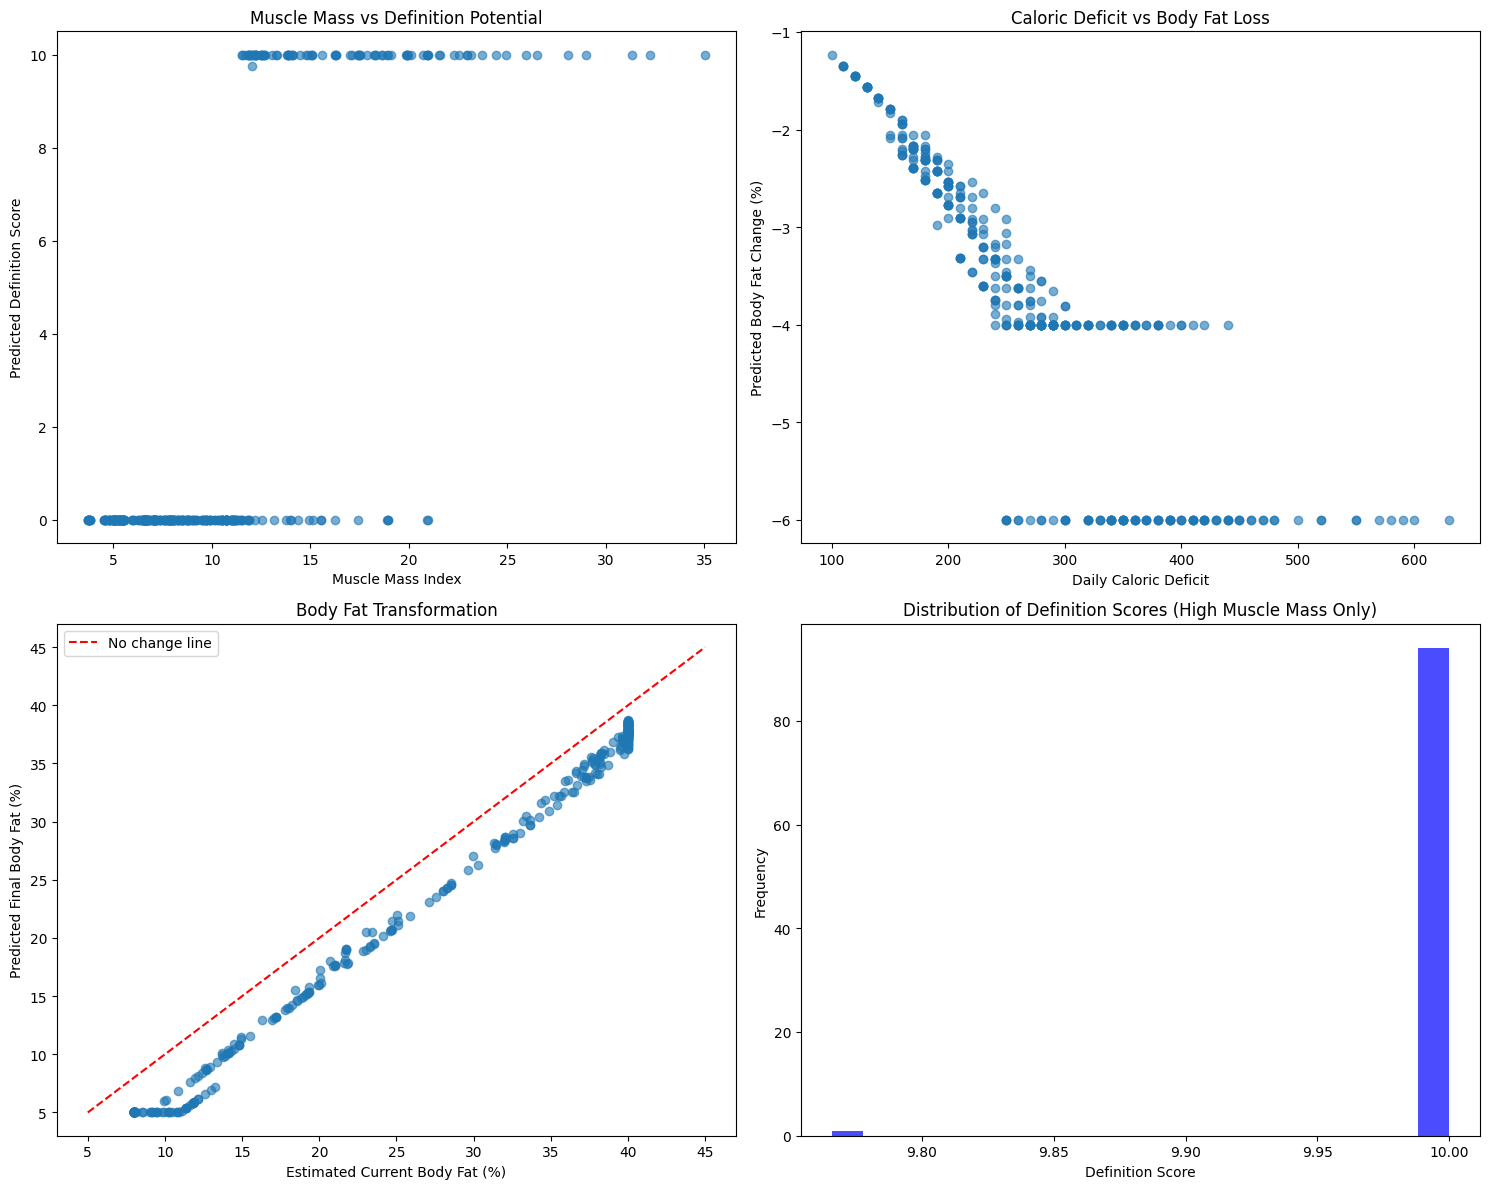

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# Plot 1: Muscle Mass Index vs Definition
axes[0,0].scatter(df['muscle_mass_index'], df['predicted_definition'], alpha=0.6)
axes[0,0].set_xlabel('Muscle Mass Index')
axes[0,0].set_ylabel('Predicted Definition Score')
axes[0,0].set_title('Muscle Mass vs Definition Potential')

# Plot 2: Daily Deficit vs Body Fat Change
axes[0,1].scatter(df['daily_deficit'], df['predicted_body_fat_change'], alpha=0.6)
axes[0,1].set_xlabel('Daily Caloric Deficit')
axes[0,1].set_ylabel('Predicted Body Fat Change (%)')
axes[0,1].set_title('Caloric Deficit vs Body Fat Loss')

# Plot 3: Current vs Predicted Body Fat
axes[1,0].scatter(df['estimated_current_bf'], df['predicted_final_bf'], alpha=0.6)
axes[1,0].plot([5, 45], [5, 45], 'r--', label='No change line')
axes[1,0].set_xlabel('Estimated Current Body Fat (%)')
axes[1,0].set_ylabel('Predicted Final Body Fat (%)')
axes[1,0].set_title('Body Fat Transformation')
axes[1,0].legend()

# Plot 4: Definition Distribution
high_muscle = df[df['predicted_definition'] > 0]['predicted_definition']
axes[1,1].hist(high_muscle, bins=20, alpha=0.7, color='blue')
axes[1,1].set_xlabel('Definition Score')
axes[1,1].set_ylabel('Frequency')
axes[1,1].set_title('Distribution of Definition Scores (High Muscle Mass Only)')

plt.tight_layout()
plt.show()

## Key Insights
Summary of findings from the analysis.

In [9]:
print('\n' + '='*50)
print('KEY INSIGHTS')
print('='*50)
print('• Individuals with high muscle mass and adequate training get definition scores > 0')
print('• Those without significant muscle mass get definition = 0 (focus on fat loss only)')
print('• Body fat percentage decrease depends on caloric deficit, muscle mass, and efficiency')
print('• Higher muscle mass helps preserve muscle during fat loss, leading to better definition')
print('• Genetic advantage and training experience influence both definition and fat loss efficiency')


KEY INSIGHTS
• Individuals with high muscle mass and adequate training get definition scores > 0
• Those without significant muscle mass get definition = 0 (focus on fat loss only)
• Body fat percentage decrease depends on caloric deficit, muscle mass, and efficiency
• Higher muscle mass helps preserve muscle during fat loss, leading to better definition
• Genetic advantage and training experience influence both definition and fat loss efficiency
